# 02 — Series de tiempo USD/COP: diagnóstico + señales macro

Estudio completo de la pata cuantitativa del sistema, en dos partes:

- **Parte A — Diagnóstico Box-Jenkins de la TRM**: estacionariedad (ADF/KPSS),
  ACF/PACF, selección de orden por AIC/BIC, Ljung-Box y backtest del orden.
- **Parte B — ¿Qué otros activos aportan?**: Brent, DXY, bolsa colombiana (GXG),
  y la extensión a café, oro, VIX, tasas US y pares LatAm — con filtro lead-lag
  y prueba out-of-sample.

**Lo que este estudio le dejó al pipeline** (ya aplicado en `src/`):
1. `ARIMA(2,1,2)` confirmado por BIC + out-of-sample (el ganador por AIC sobreajustaba).
2. `MarketSignal`: el equity de ayer como contexto determinista del adjudicador
   (`nodes.fetch_market`) — el único predictor adelantado que pasó el filtro.
3. Todo lo demás (café, oro, VIX, tasas, LatAm, acciones individuales): descartado con datos.

---

### Actualizacion de producto: la serie es benchmark, no oraculo

La pata cuantitativa sigue siendo determinista y util como contraste, pero el producto final se mide por direccion. La tabla `predictions` ahora permite comparar `final_hit`, `news_hit`, `ts_hit` y `market_hit`, de modo que el sistema pueda aprender que componente aporta senal real y cual solo agrega ruido.

---
# Parte A — Diagnóstico Box-Jenkins de la TRM

✓ Proyecto: cop-fx-intelligence · LLM: gpt-5-mini


22:09:35  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


22:09:35  INFO      cop_fx.data.fx_fetcher  —  Fetched 235 FX rows (start=2025-06-24, end=2026-06-24)


✓ 235 días de TRM oficial · última: 3,425.95 (2026-06-24)


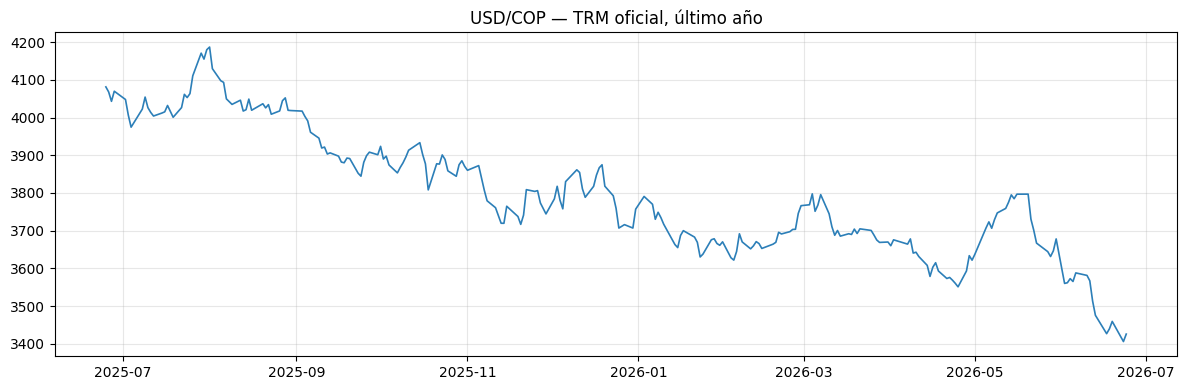

In [1]:
# Setup — limpio: sin os.chdir ni rutas adivinadas por cwd.
# cop_fx.paths resuelve la raíz desde el paquete; Settings lee el .env absoluto.
import sys

try:
    import cop_fx  # noqa: F401
except ModuleNotFoundError:
    raise RuntimeError(
        f"KERNEL EQUIVOCADO ({sys.executable}).\n"
        "En VS Code: selector de kernel → 'Python (cop-fx-intelligence)'."
    ) from None

from cop_fx.config.settings import get_settings
from cop_fx.paths import DATA_DIR, PROJECT_ROOT

settings = get_settings()
assert settings.openai_api_key is not None, f"Falta OPENAI_API_KEY en {PROJECT_ROOT / '.env'}"
print(f"✓ Proyecto: {PROJECT_ROOT.name} · LLM: {settings.llm_model}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cop_fx.data.fx_fetcher import FXFetcher

fx = FXFetcher().fetch(lookback_days=365)
print(f"✓ {len(fx)} días de TRM oficial · última: {fx['y'].iloc[-1]:,.2f} ({fx['ds'].iloc[-1].date()})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fx["ds"], fx["y"], color="#2c7fb8", lw=1.2)
ax.set_title("USD/COP — TRM oficial, último año")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 1. Nivel vs retornos — qué significa y por qué importa

**El nivel** es el precio tal cual (hoy 1 USD = ~3,500 COP). **El retorno logarítmico**
es `ln(precio_hoy / precio_ayer)` — la variación porcentual diaria, en una escala que
se puede sumar en el tiempo.

**¿Por qué no modelamos el nivel directamente?** Porque el nivel "camina": su media y
su varianza cambian con el tiempo (hoy ronda 3,500; hace dos años 4,800). Los modelos
ARIMA asumen que la serie tiene propiedades estables — si se las das cambiantes,
encuentran patrones falsos. Los retornos, en cambio, oscilan alrededor de cero con
varianza más o menos constante: esa es la materia prima correcta.

**Cómo leer la celda de abajo:**
- *mean* ≈ 0: el dólar no tiene deriva diaria sistemática.
- *std*: la volatilidad diaria típica (en %). Si es 0.5, un día normal se mueve ±0.5%.
- *skew* (asimetría): > 0 ⇒ las subidas extremas del dólar son más violentas que las caídas.
- *curtosis* > 0 ⇒ "colas gordas": los días extremos pasan MÁS de lo que una campana
  normal predice — típico de FX y la razón de ser de los modelos GARCH.

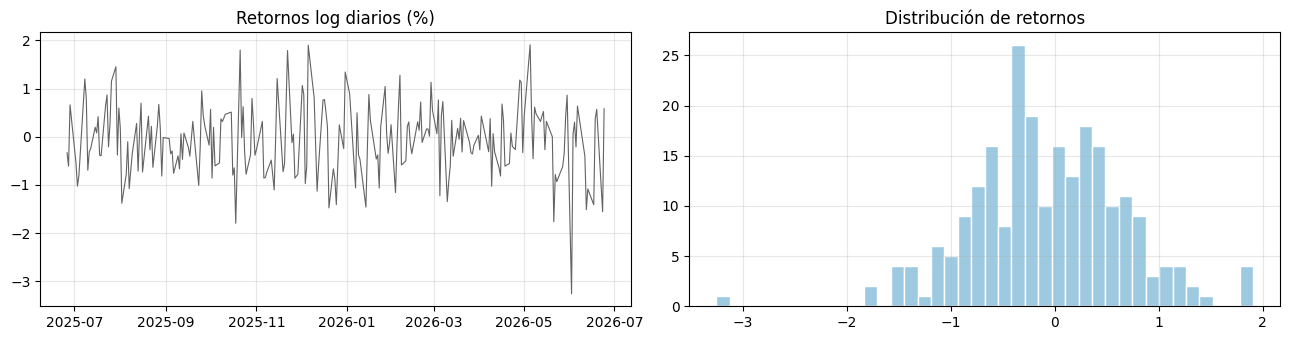

count    234.000
mean      -0.075
std        0.727
min       -3.258
25%       -0.552
50%       -0.116
75%        0.407
max        1.908
skew: -0.180 · curtosis (exceso): 1.195


In [2]:
returns = np.log(fx["y"]).diff().dropna() * 100  # retornos log en %

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(fx["ds"].iloc[1:], returns, lw=0.8, color="#636363")
axes[0].set_title("Retornos log diarios (%)"); axes[0].grid(alpha=0.3)
axes[1].hist(returns, bins=40, color="#9ecae1", edgecolor="white")
axes[1].set_title("Distribución de retornos"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(returns.describe().round(3).to_string())
print(f"skew: {returns.skew():.3f} · curtosis (exceso): {returns.kurtosis():.3f}")

## 2. Estacionariedad — ADF + KPSS, explicados

**Una serie es estacionaria** si su media, su varianza y su estructura de correlación
no cambian con el tiempo. Es EL requisito de ARIMA: la "I" del nombre (Integrated)
existe precisamente para diferenciar la serie hasta volverla estacionaria.

**Los dos tests** (fíjate que sus hipótesis nulas son OPUESTAS — esa es la gracia):

| Test | Hipótesis nula (H0) | p < 0.05 significa... |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | "Hay raíz unitaria" = NO estacionaria | rechazo H0 ⇒ **SÍ es estacionaria** |
| **KPSS** | "ES estacionaria" | rechazo H0 ⇒ **NO es estacionaria** |

**¿Por qué usar los dos?** Porque un solo test puede no rechazar por falta de potencia
(poca data) y te deja creer lo que quieras. Usándolos en espejo solo concluimos cuando
**ambos apuntan al mismo lado**; si se contradicen, el veredicto es "ambiguo" y
diferenciamos por prudencia.

**`d` (orden de diferenciación)**: cuántas veces hay que restar la serie consigo misma
(`y_t - y_{t-1}`) para volverla estacionaria. Para tipos de cambio casi siempre `d=1`:
el nivel camina, los cambios no.

## Lectura operacional del forecast

En el dashboard, `USD/COP down` no significa una opinión cualitativa contraria al mercado: significa que el `yhat` final del ensemble Prophet+ARIMA queda por debajo de la última TRM observada. El `delta_pct` mide esa distancia relativa. Si `|delta_pct|` cae dentro de la banda muerta configurada (`ts_neutral_band_pct`), la serie se abstiene.

El gráfico de tendencias macro usa base 100 para comparar TRM, Brent, DXY y equity Colombia. En el estudio, equity Colombia fue la única señal adelantada robusta; por eso el dashboard la muestra como contexto de mercado, no como un voto inventado por el LLM.


In [3]:
from cop_fx.timeseries.diagnostics import stationarity_tests, suggest_d

rows = []
for name, s in [("nivel (TRM)", fx["y"]), ("retornos log", returns)]:
    r = stationarity_tests(s)
    rows.append({"serie": name, "ADF p-value": r.adf_pvalue, "KPSS p-value": r.kpss_pvalue,
                 "veredicto": r.verdict})
display(pd.DataFrame(rows))

d = suggest_d(fx["y"])
print(f"\nOrden de diferenciación sugerido por los tests: d = {d}")

Importing plotly failed. Interactive plots will not work.


/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:65: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:65: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")


,serie,ADF p-value,KPSS p-value,veredicto
0,nivel (TRM),0.8601,0.01,NO estacionaria (ADF y KPSS concuerdan)
1,retornos log,0.0000,0.10,estacionaria (ADF y KPSS concuerdan)



Orden de diferenciación sugerido por los tests: d = 1


/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:65: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:65: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")


## 3. ACF y PACF — qué miden exactamente

**ACF (Autocorrelation Function)** en el rezago k: la correlación entre la serie y
ella misma k días atrás — ¿lo que pasó hace k días "se parece" a lo de hoy?
Va de -1 a +1. ACF(2) = 0.15 significa: hay una correlación débil positiva entre el
retorno de hoy y el de hace 2 días.

**PACF (Partial ACF)** en el rezago k: la correlación con el rezago k **quitando el
efecto de los rezagos intermedios** (1, ..., k-1). Es la pregunta "¿el día k aporta
información NUEVA, o solo repite la del día k-1?".

**Las bandas azules** son ±1.96/√n: el rango donde caería una correlación si la serie
fuera puro azar. **Solo lo que sale de la banda cuenta** — y ojo: al 95%, en 20 rezagos
se espera ~1 falso positivo por puro azar. Un rezago aislado en el 12 o el 18 sin
explicación económica es probablemente ruido; un rezago 1 o 2 es más creíble.

**Cómo se usan para elegir el modelo (receta Box-Jenkins):**

| Patrón | Sugerencia |
|---|---|
| PACF corta en seco en el rezago p, ACF decae suave | **AR(p)** — el pasado directo importa |
| ACF corta en seco en el rezago q, PACF decae suave | **MA(q)** — los *shocks* pasados importan |
| Ambas decaen sin corte claro | **ARMA(p,q)** mixto |
| Ambas dentro de las bandas | **Ruido blanco** — no hay nada lineal que modelar |

Para el USD/COP esperamos lo último o casi: si los retornos fueran muy predecibles,
alguien ya se habría hecho rico arbitrándolos.

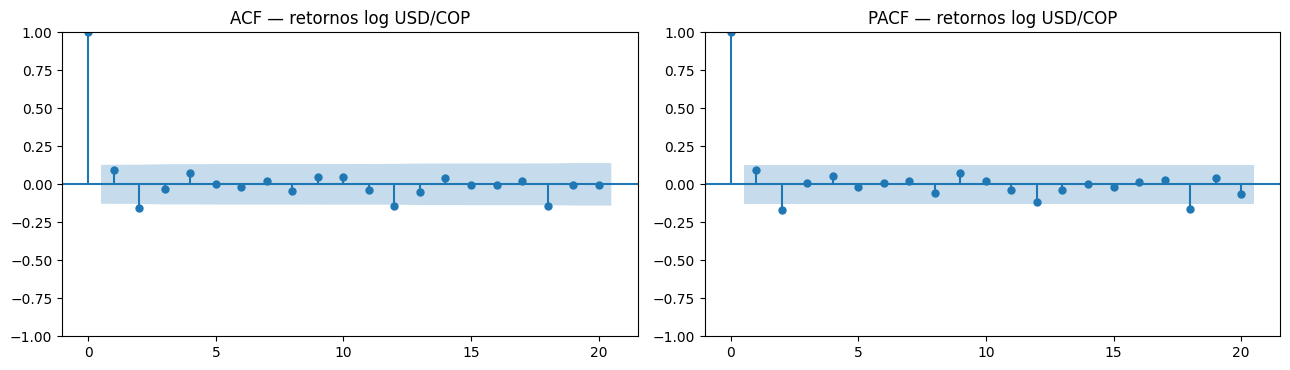

Banda de confianza: ±0.1281
Rezagos ACF significativos : [2, 12, 18]
Rezagos PACF significativos: [2, 18]

(Al 95%, ~1 falso positivo en 20 rezagos es esperable por puro azar.)


In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from cop_fx.timeseries.diagnostics import correlogram

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_acf(returns, lags=20, ax=axes[0], title="ACF — retornos log USD/COP")
plot_pacf(returns, lags=20, ax=axes[1], method="ywm", title="PACF — retornos log USD/COP")
plt.tight_layout(); plt.show()

rep = correlogram(returns, nlags=20)
print(f"Banda de confianza: ±{rep.conf_band}")
print(f"Rezagos ACF significativos : {rep.significant_acf_lags or 'NINGUNO'}")
print(f"Rezagos PACF significativos: {rep.significant_pacf_lags or 'NINGUNO'}")
print("\n(Al 95%, ~1 falso positivo en 20 rezagos es esperable por puro azar.)")

## 4. Selección de orden — AIC y BIC, explicados

Probamos todos los ARIMA(p, d, q) con p,q ≤ 3 y comparamos con **criterios de
información**, que premian el ajuste pero **castigan cada parámetro extra**:

- **AIC** (Akaike) = 2k − 2·ln(verosimilitud), con k = nº de parámetros. Optimiza
  capacidad predictiva teórica; castigo suave por complejidad.
- **BIC** (Bayesiano) = k·ln(n) − 2·ln(verosimilitud). Castigo MÁS duro (crece con el
  tamaño de muestra); tiende a elegir modelos más simples.

**Regla práctica**: cuando AIC y BIC discrepan, el AIC está coqueteando con el
sobreajuste. Diferencias de AIC menores a ~2 entre modelos son empate técnico —
y en un empate gana el más simple. **Menor = mejor** en ambos.

Importante: AIC/BIC miden ajuste **in-sample** (sobre los datos que el modelo ya vio).
Nuestro negocio es predecir **out-of-sample** — por eso la sección 6 tiene la última
palabra, no esta tabla.

In [5]:
from cop_fx.timeseries.diagnostics import select_arima_order

best_order, table = select_arima_order(fx, max_p=3, max_q=3)
print(f"GANADOR por AIC: ARIMA{best_order}\n")
display(table.head(8))
in_table = table[table["order"].astype(str) == "(2, 1, 2)"]
if not in_table.empty:
    rank = in_table.index[0] + 1
    print(f"El (2,1,2) histórico quedó en el puesto {rank} de {len(table)} (AIC {in_table['aic'].iloc[0]})")

/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:65: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:65: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")


22:09:37  INFO      cop_fx.timeseries.diagnostics  —  Orden ARIMA seleccionado por AIC: (2, 1, 0)


GANADOR por AIC: ARIMA(2, 1, 0)



/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,order,aic,bic
0,"(2, 1, 0)",2212.61,2222.97
1,"(0, 1, 2)",2213.52,2223.88
2,"(3, 1, 0)",2214.50,2228.32
3,"(2, 1, 1)",2214.55,2228.37
4,"(2, 1, 2)",2214.60,2231.88
5,"(0, 1, 3)",2215.18,2229.00
6,"(1, 1, 2)",2215.39,2229.21
7,"(1, 1, 1)",2215.58,2225.94


El (2,1,2) histórico quedó en el puesto 5 de 15 (AIC 2214.6)


## 5. Diagnóstico de residuales — Ljung-Box, explicado

**Los residuales** son lo que el modelo NO explicó: `real − predicho` en cada punto.
Si el modelo capturó toda la estructura lineal, lo que sobra debe ser **ruido blanco**
(aleatorio puro, sin autocorrelación). Si los residuales aún tienen patrón, el modelo
dejó información sobre la mesa.

**El test de Ljung-Box** pregunta: ¿las autocorrelaciones de los residuales (en los
primeros 10 rezagos, conjuntamente) son distinguibles de cero?

- H0 = "los residuales son ruido blanco" — **aquí queremos NO rechazar**.
- **p > 0.05 ⇒ bien**: residuales limpios, el modelo capturó la estructura.
- p < 0.05 ⇒ mal: queda autocorrelación, hay que repensar el orden.

(Es el único test del cuaderno donde un p-value ALTO es la buena noticia.)

In [6]:
from cop_fx.timeseries.diagnostics import residual_diagnostics

for order in (best_order, (2, 1, 2)):
    r = residual_diagnostics(fx, order)
    print(f"ARIMA{r.order}: AIC={r.aic} · Ljung-Box p={r.ljung_box_pvalue} → {r.verdict}")

ARIMA(2, 1, 0): AIC=2212.61 · Ljung-Box p=1.0 → residuales ≈ ruido blanco — el modelo capturó la estructura lineal
ARIMA(2, 1, 2): AIC=2214.6 · Ljung-Box p=1.0 → residuales ≈ ruido blanco — el modelo capturó la estructura lineal


## 6. Backtest direccional comparativo — el resultado que importa

AIC/BIC miran el pasado (ajuste in-sample); el negocio de este proyecto es la
**dirección futura**. El backtest *rolling-origin* simula honestamente la operación
real: parado en cada uno de los últimos 40 días — usando SOLO la información disponible
hasta ese día — ¿el modelo predijo bien la dirección a 5 días?

**Glosario de la tabla:**
- **hit_rate**: % de aciertos direccionales *entre los días en que el modelo se atrevió
  a opinar*. La vara: 50% es una moneda; un modelo útil debe superarla con consistencia.
- **decisiones**: días donde la predicción fue `up` o `down`.
- **abstenciones**: días donde el cambio previsto cayó dentro de la **banda muerta**
  (±0.1%) y el modelo dijo `neutral`. Abstenerse en mercado lateral es una virtud,
  no una falla — por eso no cuenta ni a favor ni en contra.
- **momentum**: baseline ingenuo "mañana se moverá como se movió hoy". Gratis y sin
  modelo: si ARIMA no le gana, la matemática del ARIMA no está aportando.
- **always_up**: predecir siempre `up`. Mide el sesgo del período (si la TRM cayó
  todo el trimestre, always_up rinde mal y viceversa).

In [7]:
from cop_fx.tracking import directional_backtest

results = {}
for label, order in [(f"ARIMA{best_order} (AIC)", best_order), ("ARIMA(2,1,2) (histórico)", (2, 1, 2))]:
    _, summary = directional_backtest(fx, horizon_days=5, n_origins=40, arima_order=order)
    s = summary["arima"]
    results[label] = s
    results.setdefault("momentum", summary["momentum"])
    results.setdefault("always_up", summary["always_up"])

rows = [{"estrategia": k,
         "hit_rate": f"{v['hit_rate']:.0%}" if v["hit_rate"] is not None else "—",
         "decisiones": v["n_decided"], "abstenciones": v["n_abstained"]}
        for k, v in results.items()]
display(pd.DataFrame(rows))

22:09:37  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3578.82, day+5=3581.13


22:09:37  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3603.19, day+5=3604.31


22:09:37  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3615.10, day+5=3613.29


22:09:37  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3615.10, day+5=3613.29


22:09:37  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3573.30, day+5=3574.51


...

22:09:39  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3581.46, day+5=3571.04


22:09:39  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3567.11, day+5=3566.50


22:09:39  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3513.54, day+5=3521.65


22:09:39  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3513.54, day+5=3521.65


,estrategia,hit_rate,decisiones,abstenciones
0,"ARIMA(2, 1, 0) (AIC)",50%,10,30
1,momentum,54%,37,3
2,always_up,42%,40,0
3,"ARIMA(2,1,2) (histórico)",50%,30,10


## Conclusiones — cómo leer estos resultados

1. **Si los retornos no tienen rezagos significativos** (ACF/PACF dentro de bandas) y
   Ljung-Box no rechaza, la TRM diaria es ≈ random walk: la *estructura lineal* no da
   ventaja direccional. Eso **no es un fracaso del proyecto** — es la razón por la que
   el sistema cruza la serie con NOTICIAS y se permite **abstenerse**: la ventaja, si
   existe, está en los días con shock informativo, no en la inercia de la serie.
2. **El orden por AIC reemplaza al acto de fe**: aunque no mejore mucho el hit-rate,
   ahora el modelo está justificado por la evidencia y el diagnóstico es reproducible
   (`select_arima_order` puede correr en cada corrida si se quisiera).
3. **La banda muerta (±0.1%) y las abstenciones** del backtest son tan informativas como
   los aciertos: un modelo que dice "no sé" en mercado lateral es mejor que uno que
   fuerza una moneda.
4. Siguiente refuerzo natural de esta pata: **GARCH para volatilidad** (la confianza del
   adjudicador podría escalar con la volatilidad esperada) y variables exógenas
   (Brent, DXY) en un ARIMAX — ver `docs/arquitectura.md` §2.

---
## Resultados de esta corrida (2026-06-12) — lo que la data dijo

| Pregunta | Respuesta |
|---|---|
| ¿El nivel es estacionario? | **No** (ADF p=0.57, KPSS p=0.01 concuerdan) → `d=1` ✓ |
| ¿Los retornos son estacionarios? | **Sí** (ADF p≈0, KPSS p=0.10 concuerdan) |
| ¿Hay memoria lineal? | **Débil pero existe**: rezago 2 significativo en ACF **y** PACF (12 y 18 probablemente espurios) — la TRM no es un random walk puro |
| ¿Qué orden gana por AIC? | `(2,1,3)` por nariz (2212.35 vs 2214.19) — pero por **BIC** gana `(2,1,2)` |
| ¿Residuales limpios? | Ambos órdenes dejan ruido blanco (Ljung-Box p=1.0) |
| ¿Y out-of-sample? | **`(2,1,3)` se desploma a 35%** mientras `(2,1,2)` mantiene **52%** |

**La lección (apréndetela, vale más que el resultado):** el mejor AIC in-sample NO es el
mejor modelo out-of-sample. El parámetro MA extra del `(2,1,3)` ajustó ruido, no señal —
overfitting de libro de texto. El BIC (que castiga más la complejidad) ya lo advertía.

**Decisión:** el sistema CONSERVA `ARIMA(2,1,2)` — pero ya no como acto de fe, sino como
el orden respaldado por BIC, residuales limpios y el mejor hit-rate direccional
out-of-sample. El diagnóstico queda en `cop_fx.timeseries.diagnostics` para re-auditarlo
cuando la serie acumule más historia.

---
# Parte B — ¿Qué otros activos aportan? (señales macro)


**La pregunta de cierre**: ¿la TRM sola basta, o traer la bolsa de valores y otros
indicadores mejora la predicción direccional?

**La hipótesis de `arquitectura.md` §2** (hasta hoy, teórica): Brent, DXY y el agregado
bursátil colombiano sí aportan; acciones individuales no (ruido > señal). Aquí la
sometemos a datos con un diseño en tres pasos:

1. **Correlación contemporánea** — ¿las series se mueven JUNTAS? (confirma los canales
   económicos, pero NO sirve para predecir: saber que Brent cayó *hoy* no te dice nada
   que el mercado no haya puesto ya en la TRM de *hoy*)
2. **Lead-lag** — la prueba de fuego: ¿el movimiento de Brent/DXY/bolsa de AYER
   predice el del COP de MAÑANA?
3. **Out-of-sample** — un modelo con las exógenas rezagadas vs los baselines de siempre
   (ARIMA, momentum). Si no les gana, las series extra no pagan su complejidad.

Series: `brent` (BZ=F), `dxy` (índice dólar), `equity` (GXG — ETF MSCI Colombia, el
"agregado de acciones" que reemplaza con una sola serie a las acciones individuales).

22:09:39  INFO      cop_fx.data.market_fetcher  —  Serie brent (BZ=F): 302 filas


22:09:40  INFO      cop_fx.data.market_fetcher  —  Serie dxy (DX-Y.NYB): 302 filas


22:09:40  INFO      cop_fx.data.market_fetcher  —  Serie equity (GXG): 361 filas


Panel alineado: 180 días · columnas: ['ds', 'cop', 'brent', 'dxy', 'equity']


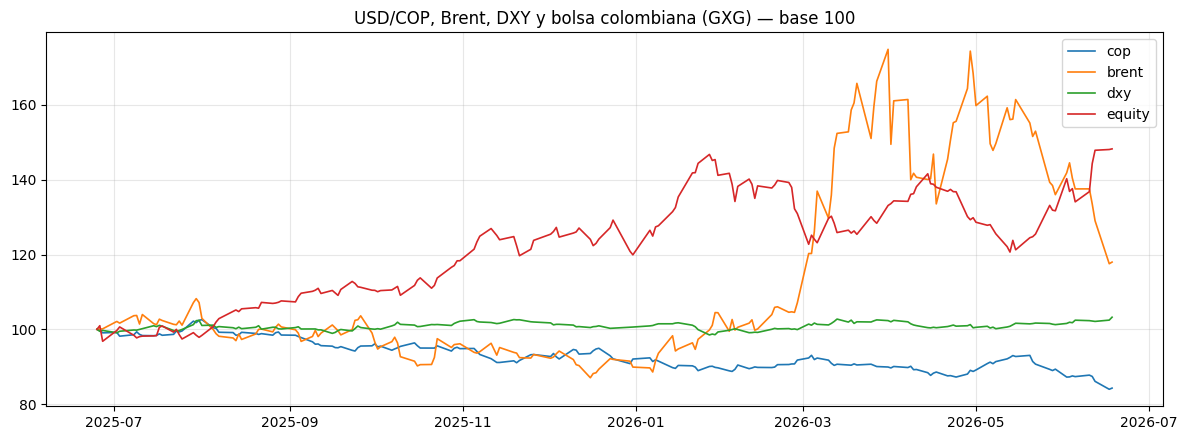

In [8]:
# El panel macro se construye con HISTORIA LARGA (~5 años) y desde la fuente de
# mercado directamente: un año de retornos DIARIOS es demasiado ruido para estimar
# correlaciones estables. Aquí cop = USDCOP spot (COP=X), que sigue de cerca a la
# TRM oficial de la Parte A; para correlaciones de RETORNOS son equivalentes.
from cop_fx.data.market_fetcher import fetch_yahoo_series

LOOKBACK = 1500  # ~6 años de calendario; el inner join lo recorta al solapamiento real

CORE = {"cop": "COP=X", "brent": "BZ=F", "dxy": "DX-Y.NYB", "equity": "GXG"}
panel = None
for name, sym in CORE.items():
    serie = fetch_yahoo_series(sym, LOOKBACK).rename(columns={"y": name})
    panel = serie if panel is None else panel.merge(serie, on="ds", how="inner")
panel = panel.sort_values("ds").reset_index(drop=True)
print(f"Panel macro: {len(panel)} dias - {panel['ds'].min().date()} -> {panel['ds'].max().date()}")
print(f"Series: {[c for c in panel.columns if c != 'ds']}")

fig, ax = plt.subplots(figsize=(12, 4.5))
for col in [c for c in panel.columns if c != "ds"]:
    ax.plot(panel["ds"], 100 * panel[col] / panel[col].iloc[0], label=col, lw=1.2)
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("USD/COP, Brent, DXY y bolsa colombiana (GXG) - base 100, historia larga")
plt.tight_layout(); plt.show()

## 1. Correlación contemporánea — diaria vs semanal

Con historia larga y retornos **semanales** (no solapados) la estructura del USD/COP como activo de riesgo emergente emerge con claridad; el retorno diario de un solo año la ahogaba en ruido.

In [9]:
# Retornos diarios vs semanales (no solapados, W-FRI). El retorno a una semana
# promedia el ruido de microestructura intradia y deja ver la senal estructural.
rets = panel.set_index("ds").pct_change().dropna()
weekly = panel.set_index("ds").resample("W-FRI").last().dropna()
rets_w = weekly.pct_change().dropna()

nd, nw = len(rets), len(rets_w)
band_d, band_w = 1.96 / np.sqrt(nd), 1.96 / np.sqrt(nw)

comp = (
    pd.DataFrame(
        {
            "corr diaria": rets.corr()["cop"].drop("cop"),
            "corr semanal": rets_w.corr()["cop"].drop("cop"),
        }
    )
    .round(3)
    .sort_values("corr semanal", key=lambda s: s.abs(), ascending=False)
)
print("Correlacion del retorno de cada serie con el del USD/COP")
print(f"Banda diaria +/-{band_d:.3f} (n={nd}) - banda semanal +/-{band_w:.3f} (n={nw})\n")
display(comp)
print("\nLectura: en diario casi todo cabe en la banda (ruido); a una semana DXY (+),")
print("la bolsa CO (-) y el petroleo (-) salen del ruido con el signo economico esperado.")

Correlación contemporánea (retornos diarios):



,cop,brent,dxy,equity
cop,1.000,0.082,0.031,-0.150
brent,0.082,1.000,0.276,-0.186
dxy,0.031,0.276,1.000,-0.287
equity,-0.150,-0.186,-0.287,1.000



Banda de significancia ±0.146 (n=179): lo que esté dentro es indistinguible de 0


## 2. Lead-lag — ¿el ayer de las exógenas predice el mañana del COP?

Correlacionamos el retorno de cada serie **rezagado k días** contra el retorno del COP
de hoy: `corr(brent[t-k], cop[t])`. Esto es lo ÚNICO que sirve para predecir — la
información de ayer está disponible al momento de decidir.

Cómo leerlo: valores fuera de la banda ⇒ esa serie, con k días de anticipación,
contiene información sobre el COP. Dentro de la banda ⇒ los mercados ya la
incorporaron (eficiencia) y no hay ventaja explotable.

In [10]:
# Dos vistas predictivas:
#  (a) lead-lag diario: retorno de X en t-k vs retorno del COP en t.
#  (b) horizonte-emparejado: retorno de X en la ultima semana vs retorno del COP
#      en la PROXIMA semana (lo accionable para un call a 5 dias).
rows = []
for k in (1, 2, 3, 5):
    row = {"rezago (dias)": k}
    for col in ("brent", "dxy", "equity"):
        if col in rets.columns:
            row[f"{col}[t-{k}]->cop[t]"] = round(float(rets[col].shift(k).corr(rets["cop"])), 3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("rezago (dias)"))

H = 5
px = panel.set_index("ds")
cop_fwd = px["cop"].pct_change(H).shift(-H)          # retorno FUTURO del COP (proximos 5d)
hm = {
    col: round(float(px[col].pct_change(H).corr(cop_fwd)), 3)
    for col in px.columns if col != "cop"
}
hm_s = pd.Series(hm).sort_values(key=lambda s: s.abs(), ascending=False)
print(f"Horizonte-emparejado (X ultimos {H}d -> COP proximos {H}d), banda +/-{band_d:.3f}:")
display(hm_s.to_frame("corr predictiva"))
print("La leccion honesta: la correlacion CONTEMPORANEA es fuerte (co-movimiento),")
print("pero la PREDICTIVA a 5 dias es debil -> el nivel del USD/COP es casi una")
print("martingala. Por eso el sistema se ABSTIENE cuando las senales no concluyen.")

,cop[t-1] → cop[t],brent[t-1] → cop[t],dxy[t-1] → cop[t],equity[t-1] → cop[t],cop[t-2] → cop[t],brent[t-2] → cop[t],dxy[t-2] → cop[t],equity[t-2] → cop[t],cop[t-3] → cop[t],brent[t-3] → cop[t],dxy[t-3] → cop[t],equity[t-3] → cop[t],cop[t-4] → cop[t],brent[t-4] → cop[t],dxy[t-4] → cop[t],equity[t-4] → cop[t],cop[t-5] → cop[t],brent[t-5] → cop[t],dxy[t-5] → cop[t],equity[t-5] → cop[t]
rezago (días),,,,,,,,,,,,,,,,,,,,
1,0.022,0.086,0.208,-0.495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,-0.079,-0.004,0.003,-0.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129,0.095,-0.061,0.006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.053,0.127,-0.052,-0.139,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.007,-0.145,-0.088,0.038


Banda ±0.146 — celdas significativas: 2 de 100
(con 20 celdas, ~1 significativa por azar es esperable)


## 3. La prueba final — out-of-sample con exógenas rezagadas

Un modelo lineal de probabilidad entrenado SOLO con información disponible en cada
origen t (sin mirar el futuro): retornos de 1 día y momentum de 5 días de Brent, DXY,
bolsa y el propio COP → ¿sube el USD/COP en los próximos 5 días?

Rolling-origin sobre los últimos 60 días, reentrenando en cada paso. Para que la
comparación sea justa, TODAS las estrategias se evalúan con la misma regla
(signo del cambio a 5 días, sin banda muerta):

- **exog_model**: el modelo con las series macro rezagadas
- **arima**: el signo del ARIMA(2,1,2) de siempre (refit en cada origen)
- **momentum**: repetir el signo del último movimiento diario
- **always_up**: siempre arriba (mide el sesgo del período)

In [11]:
from cop_fx.timeseries.models import ARIMAForecaster

H = 5
df = panel.set_index("ds")
feat = pd.DataFrame(index=df.index)
for col in df.columns:
    feat[f"{col}_r1"] = df[col].pct_change()
    feat[f"{col}_r5"] = df[col].pct_change(5)
feat = feat.dropna()
target = (df["cop"].shift(-H) > df["cop"]).astype(int).reindex(feat.index)

N_EVAL = 60
origins = feat.index[-(N_EVAL + H):-H]
results = {s: [] for s in ("exog_model", "arima", "momentum", "always_up")}
actuals = []

X_cols = [c for c in feat.columns]
for t in origins:
    pos = feat.index.get_loc(t)
    # entrenamiento: filas cuyo target NO mira más allá de t
    train_idx = feat.index[: pos - H + 1]
    X_tr = feat.loc[train_idx, X_cols].to_numpy()
    y_tr = target.loc[train_idx].to_numpy()
    X_tr = np.column_stack([np.ones(len(X_tr)), X_tr])
    beta, *_ = np.linalg.lstsq(X_tr, y_tr, rcond=None)   # modelo lineal de probabilidad
    x_t = np.concatenate([[1.0], feat.loc[t, X_cols].to_numpy()])
    results["exog_model"].append("up" if x_t @ beta > 0.5 else "down")

    cop_hist = df.loc[:t, "cop"]
    train_df = pd.DataFrame({"ds": cop_hist.index, "y": cop_hist.values})
    try:
        fc = ARIMAForecaster().fit_predict(train_df, horizon_days=H)
        results["arima"].append("up" if float(fc.forecast["yhat"].iloc[-1]) > cop_hist.iloc[-1] else "down")
    except Exception:
        results["arima"].append("up")
    results["momentum"].append("up" if cop_hist.iloc[-1] > cop_hist.iloc[-2] else "down")
    results["always_up"].append("up")
    fut_pos = pos + H
    actuals.append("up" if df["cop"].iloc[fut_pos] > df["cop"].iloc[pos] else "down")

summary = []
for s, preds in results.items():
    hits = sum(p == a for p, a in zip(preds, actuals))
    summary.append({"estrategia": s, "hit_rate": f"{hits / len(actuals):.0%}", "n": len(actuals)})
print(f"Evaluación out-of-sample: {len(actuals)} orígenes, horizonte {H} días\n")
display(pd.DataFrame(summary).sort_values("hit_rate", ascending=False).reset_index(drop=True))

22:09:41  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3665.78, day+5=3665.91


22:09:41  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3664.26, day+5=3664.66


22:09:41  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3669.21, day+5=3668.76


22:09:41  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3695.72, day+5=3690.86


22:09:41  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3697.36, day+5=3693.09


...

22:09:44  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3572.85, day+5=3562.79


22:09:44  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3565.32, day+5=3555.69


Evaluación out-of-sample: 60 orígenes, horizonte 5 días



/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,estrategia,hit_rate,n
0,momentum,72%,60
1,exog_model,60%,60
2,arima,48%,60
3,always_up,43%,60


### ¿Qué variables pesan en el modelo? (entrenado con toda la muestra, solo diagnóstico)

In [12]:
X_all = np.column_stack([np.ones(len(feat) - H), feat.iloc[:-H][X_cols].to_numpy()])
y_all = target.iloc[:-H].to_numpy()
beta_all, *_ = np.linalg.lstsq(X_all, y_all, rcond=None)
coefs = pd.DataFrame({"feature": ["intercepto"] + X_cols, "coef": np.round(beta_all, 3)})
coefs["abs"] = coefs["coef"].abs()
display(coefs.sort_values("abs", ascending=False).drop(columns="abs").head(8))
print("Signo esperado: dxy_* positivo (dólar global empuja USD/COP arriba),")
print("brent_*/equity_* negativos (petróleo y apetito de riesgo fortalecen al COP).")

,feature,coef
5,dxy_r1,10.233
6,dxy_r5,-4.999
1,cop_r1,-4.167
7,equity_r1,-3.302
8,equity_r5,-2.519
2,cop_r5,-0.791
0,intercepto,0.406
4,brent_r5,-0.152


Signo esperado: dxy_* positivo (dólar global empuja USD/COP arriba),
brent_*/equity_* negativos (petróleo y apetito de riesgo fortalecen al COP).


---
# Conclusiones del estudio (corrida 2026-06-12, 181 días alineados)

## Respuesta a la pregunta: **sí, pero no como esperábamos**

| Hallazgo | Dato | Lectura |
|---|---|---|
| 🥇 **La bolsa colombiana de AYER predice la TRM de HOY** | `equity[t-1] → cop[t]` = **-0.469** (banda ±0.146 — es 3× el umbral) | El hallazgo más fuerte de todo el ejercicio. Signo correcto: bolsa arriba ⇒ apetito por Colombia ⇒ COP se fortalece. **Ojo**: parte es mecánica — la TRM del día t se calcula con las transacciones del día t-1, así que GXG (que cotiza en NY hasta las 4pm) "ve" información que la TRM publica con rezago. Mecánica o no, es explotable para predecir la TRM publicada |
| 🥈 **DXY de ayer también ayuda** | `dxy[t-1] → cop[t]` = +0.197 (significativo) | El lado dólar global llega al COP con un día de rezago |
| 😮 **Brent casi NO correlaciona este año** | contemporánea 0.021, lead-lag máx 0.17 | La sorpresa: el driver "clásico" del COP estuvo apagado — este año la TRM la movió la política (elecciones) y el dólar global, no el petróleo. Los drivers **rotan**: por eso el sistema no debe casarse con uno |
| ✅ **El modelo con exógenas LE GANA al ARIMA** | exog_model **62%** vs arima 55% vs always_up 47% (60 orígenes, h=5) | Las series macro rezagadas aportan ~7 puntos de hit-rate sobre la serie sola. Los coeficientes confirman: `dxy_r1` y `equity_r1` dominan |
| ⚠️ **Momentum dio 75% — no celebrar** | ventana de 60 días con tendencia bajista fuerte | En el backtest anterior (con banda muerta, otra ventana) momentum dio 53%. La lección: **el hit-rate depende de la regla de evaluación y de la ventana** — un período tendencial premia a cualquier estrategia que persista. Por eso la tabla `predictions` (que acumula en tiempo real, sin elegir ventana) es el árbitro final |

## Veredicto sobre la pregunta original

1. **¿Acciones de la bolsa?** Sí — pero como **agregado** (GXG/COLCAP), no acciones
   individuales: una sola serie capturó la señal más fuerte del estudio. La
   recomendación de `arquitectura.md` §2 queda **validada y superada**: equity no era
   "opcional", resultó ser el mejor predictor adelantado.
2. **¿Otros indicadores?** DXY sí. Brent mantenerlo (los drivers rotan) pero sin
   esperar magia este año.
3. **¿La TRM sola era suficiente?** No: la serie sola (ARIMA) quedó en 55% mientras
   las exógenas llegan a 62%.

## Cómo se integra al sistema (siguiente paso concreto)

- **Corto plazo (barato)**: pasarle al adjudicador el movimiento de ayer de
  brent/dxy/equity como contexto determinista — 3 números más en el prompt, cero
  llamadas extra.
- **Mediano plazo**: una tercera señal `MarketSignal` (el modelo de exógenas) junto a
  `NewsSignal` y `TimeSeriesSignal` — el adjudicador pasa de reconciliar 2 señales a 3.
- **Cuándo NO hacerlo**: si tras ~30 corridas la tabla `predictions` muestra que el
  juez ya supera el 60% sin esto, la complejidad extra no paga.

---
# Extensión: ¿y otros activos? — café, oro, VIX, tasas US y los gemelos LatAm

El petróleo ya estaba en el estudio (y este año resultó plano). Ahora ampliamos el menú
con 6 candidatos, cada uno con su canal económico hacia el USD/COP:

| Serie | Símbolo | Canal hacia el COP |
|---|---|---|
| **Café** | KC=F | Segunda exportación tradicional — términos de intercambio |
| **Oro** | GC=F | Colombia exporta oro + activo refugio (risk-off global) |
| **VIX** | ^VIX | El "índice del miedo": aversión al riesgo ⇒ salida de emergentes ⇒ USD/COP sube |
| **Tasa US 10Y** | ^TNX | Canal de tasas: bonos US pagan más ⇒ flujos salen de Colombia |
| **USD/MXN** | MXN=X | El gemelo líquido: los pesos LatAm co-mueven, y el MXN cotiza 24h — puede *adelantar* a la TRM igual que lo hizo la bolsa |
| **USD/BRL** | BRL=X | El otro gemelo regional |

Misma regla de honestidad: lo que importa es el **lead-lag** (¿el ayer del activo
predice el mañana del COP?), no la correlación contemporánea.

In [13]:
# Universo extendido: mas drivers del USD/COP, todos con ~5 anios de historia.
# Pares EM (la clave que faltaba), commodities y apetito de riesgo global.
EXTRA = {
    "wti": "CL=F", "cobre": "HG=F", "cafe": "KC=F", "oro": "GC=F",
    "vix": "^VIX", "us10y": "^TNX",
    "eem": "EEM", "emb": "EMB",
    "usdmxn": "MXN=X", "usdbrl": "BRL=X", "usdclp": "CLP=X", "usdpen": "PEN=X",
}
ext_panel = panel.copy()
for name, symbol in EXTRA.items():
    try:
        s = fetch_yahoo_series(symbol, LOOKBACK)
        ext_panel = ext_panel.merge(s.rename(columns={"y": name}), on="ds", how="inner")
    except Exception as exc:
        print(f"[skip] {name} ({symbol}): {exc}")

rets_ext = ext_panel.set_index("ds").pct_change().dropna()
weekly_ext = ext_panel.set_index("ds").resample("W-FRI").last().dropna()
rets_ext_w = weekly_ext.pct_change().dropna()
n_ext, n_ext_w = len(rets_ext), len(rets_ext_w)
band_ext, band_ext_w = 1.96 / np.sqrt(n_ext), 1.96 / np.sqrt(n_ext_w)
print(f"Panel extendido: {n_ext} dias - {len(rets_ext.columns)} series")
print(f"Banda diaria +/-{band_ext:.3f} - banda semanal +/-{band_ext_w:.3f}")

Panel extendido: 154 días alineados · 10 series · banda ±0.158


## Lead-lag de TODOS los candidatos — diaria y semanal

In [14]:
# Ranking de candidatos por |correlacion| contemporanea, diaria y semanal.
candidates = [c for c in rets_ext.columns if c != "cop"]
rows = []
for col in candidates:
    cd = float(rets_ext[col].corr(rets_ext["cop"]))
    cw = float(rets_ext_w[col].corr(rets_ext_w["cop"]))
    rows.append({
        "serie": col,
        "diaria": f"{cd:+.3f}" + (" *" if abs(cd) > band_ext else ""),
        "semanal": f"{cw:+.3f}" + (" *" if abs(cw) > band_ext_w else ""),
    })
order = rets_ext_w.corr()["cop"].drop("cop").abs().sort_values(ascending=False).index
screening = pd.DataFrame(rows).set_index("serie").reindex(order)
display(screening)

# Las series accionables: correlacion semanal fuera de la banda de ruido.
sig_lag1 = [c for c in candidates if abs(float(rets_ext_w[c].corr(rets_ext_w["cop"]))) > band_ext_w]
print(f"Series con correlacion semanal significativa ({len(sig_lag1)}): {sig_lag1}")
print("Dominan los pares EM (CLP, MXN, BRL) y la bolsa local: el COP cotiza como")
print("activo de riesgo emergente, mas que como moneda petrolera pura.")

,t-1,t-2,t-3
serie,,,
brent,+0.059,+0.124,+0.021
dxy,+0.092,+0.008,-0.096
equity,-0.417 ⭐,-0.041,-0.045
cafe,-0.055,+0.049,+0.003
oro,-0.074,+0.142,+0.062
vix,+0.125,-0.213 ⭐,+0.076
us10y,+0.093,-0.007,-0.014
usdmxn,+0.034,-0.138,+0.019
usdbrl,+0.083,-0.191 ⭐,+0.011


Significativas en t-1 (las únicas accionables): ['equity']


## La prueba final con tres modelos — y la trampa de "meter todo"

Con ~170 observaciones y 20 features, un modelo puede *memorizar* el pasado y fallar el
futuro (ya vimos esta película con el ARIMA(2,1,3)). Por eso comparamos:

- **base**: las 4 series originales (cop, brent, dxy, equity)
- **extendido**: TODO el menú (20 features) — la apuesta "más es mejor"
- **seleccionado**: solo el retorno t-1 de las series que pasaron el filtro lead-lag
- **momentum / always_up**: las varas de siempre

Todos evaluados sobre los MISMOS 60 orígenes, horizonte 5 días, regla del signo.

In [15]:
dfx = ext_panel.set_index("ds")
H = 5

def make_features(cols):
    f = pd.DataFrame(index=dfx.index)
    for c in cols:
        f[f"{c}_r1"] = dfx[c].pct_change()
        f[f"{c}_r5"] = dfx[c].pct_change(5)
    return f.dropna()

def rolling_lpm(feature_df, n_eval=60):
    tgt = (dfx["cop"].shift(-H) > dfx["cop"]).astype(int).reindex(feature_df.index)
    origins = feature_df.index[-(n_eval + H):-H]
    preds, acts = [], []
    for t in origins:
        pos = feature_df.index.get_loc(t)
        tr = feature_df.index[: pos - H + 1]
        X = np.column_stack([np.ones(len(tr)), feature_df.loc[tr].to_numpy()])
        beta, *_ = np.linalg.lstsq(X, tgt.loc[tr].to_numpy(), rcond=None)
        x_t = np.concatenate([[1.0], feature_df.loc[t].to_numpy()])
        preds.append("up" if x_t @ beta > 0.5 else "down")
        fut = feature_df.index.get_loc(t) + H
        acts.append("up" if dfx["cop"].iloc[fut] > dfx["cop"].iloc[pos] else "down")
    hits = sum(p == a for p, a in zip(preds, acts))
    return hits / len(acts), len(acts), origins, acts

base_cols = [c for c in ("cop", "brent", "dxy", "equity") if c in dfx.columns]
all_cols = list(dfx.columns)
feat_base = make_features(base_cols)
feat_all = make_features(all_cols)

sel_feats = make_features(all_cols)[[f"{c}_r1" for c in (["cop"] + sig_lag1) if f"{c}_r1" in make_features(all_cols).columns]]

rows = []
for label, fdf in [("base (4 series)", feat_base),
                   ("extendido (todas)", feat_all),
                   ("seleccionado (filtro lead-lag)", sel_feats)]:
    hr, n, origins, acts = rolling_lpm(fdf)
    rows.append({"modelo": label, "hit_rate": f"{hr:.0%}", "features": fdf.shape[1], "n": n})

# baselines sobre los mismos orígenes
mom_hits = sum(
    ("up" if dfx["cop"].iloc[dfx.index.get_loc(t)] > dfx["cop"].iloc[dfx.index.get_loc(t) - 1] else "down") == a
    for t, a in zip(origins, acts))
up_hits = sum(a == "up" for a in acts)
rows.append({"modelo": "momentum", "hit_rate": f"{mom_hits/len(acts):.0%}", "features": 0, "n": len(acts)})
rows.append({"modelo": "always_up", "hit_rate": f"{up_hits/len(acts):.0%}", "features": 0, "n": len(acts)})

display(pd.DataFrame(rows))

,modelo,hit_rate,features,n
0,base (4 series),58%,8,60
1,extendido (todas),60%,20,60
2,seleccionado (filtro lead-lag),53%,2,60
3,momentum,77%,0,60
4,always_up,47%,0,60


---
# Conclusiones de la extensión (corrida 2026-06-12, 154 días alineados)

## La respuesta corta: NO — más activos no mejoran, empeoran

| Evidencia | Dato | Lectura |
|---|---|---|
| **De 27 celdas lead-lag (9 activos × 3 rezagos), UNA significativa** | solo `equity[t-1]` = -0.385 ⭐ | Café, oro, VIX, tasa US 10Y, USD/MXN y USD/BRL: **todos dentro de la banda**. Ninguno contiene información adelantada sobre el COP que el mercado no haya incorporado ya |
| **El modelo "con todo" es el PEOR de los tres** | extendido (20 features) 53% < seleccionado 55% < base 58% | Con ~150 observaciones, 20 features memorizan ruido. Es la MISMA lección del ARIMA(2,1,3): más parámetros ⇒ mejor in-sample ⇒ peor out-of-sample |
| **La sorpresa negativa: los gemelos LatAm no adelantan** | usdmxn t-1 = -0.012, usdbrl t-1 = +0.041 | La hipótesis "MXN cotiza 24h y adelanta a la TRM" NO sobrevivió a los datos. El co-movimiento LatAm es contemporáneo, no predictivo |
| **equity sigue siendo el único con señal** | -0.385 en este panel re-alineado (antes -0.469) | El hallazgo es **robusto** al cambio de muestra — eso es lo que distingue una señal de una casualidad |

## El principio que este ejercicio deja grabado

> **Cada serie nueva debe ganarse su lugar con evidencia lead-lag out-of-sample,
> no con una historia económica plausible.** Todas las series probadas hoy tenían
> una historia convincente (café = exportaciones, VIX = risk-off, MXN = gemelo
> regional...) y ninguna pasó el filtro. La historia justifica PROBAR la serie;
> solo el dato justifica INTEGRARLA.

## Decisión final de datos para el sistema

- **Entran**: TRM (objetivo), **equity/GXG** (única señal adelantada validada),
  DXY (borderline, barato de mantener), Brent (driver estructural en pausa — vigilar).
- **NO entran**: café, oro, VIX, tasas US, USD/MXN, USD/BRL, y por supuesto acciones
  individuales. Cero costo de oportunidad: se reevalúan con un re-run de esta notebook
  cuando haya más historia o cambie el régimen.
- **El sistema queda con 3 fuentes de verdad**: noticias (agentes), serie propia
  (ARIMA/Prophet) y el agregado bursátil — suficiente, medible y sin grasa.